# 소상공인 지속가능성 예측 모델 (Random Forest + SMOTE)

**참조 논문**: 박준식(2022) 랜덤포레스트를 활용한 소상공인 사업 지속가능성 예측모형 개발연구  
**데이터**: 2023년 소상공인 실태조사 (40,000건 × 149 피처)

### 실행 전 준비
1. Google Drive에 `features.xlsx` 업로드
2. 아래 `DRIVE_PATH` 변수에 파일 경로 설정
3. 런타임 → 모두 실행

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import glob
results = glob.glob('/content/drive/MyDrive/**/features.xlsx', recursive=True)
for r in results:
    print(r)

/content/drive/MyDrive/features.xlsx


In [3]:
# ── 설정값 (여기만 수정) ───────────────────────────────────────────
DRIVE_PATH = '/content/drive/MyDrive/features.xlsx'  # Drive 내 파일 경로
N_ITER     = 30    # RandomizedSearchCV 탐색 횟수 (30 ≈ 15~25분, 100 ≈ 1시간+)
RANDOM_STATE = 42

## 0. 환경 설정

In [4]:
# 패키지 설치
!pip install imbalanced-learn -q

# 한글 폰트 설치 (나눔고딕)
!apt-get install -y fonts-nanum -qq

# 폰트 캐시 갱신
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)
print('설치 완료')

Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
설치 완료


In [5]:
# Google Drive 마운트
from google.colab import drive
drive.mount('/content/drive')
print('Drive 마운트 완료')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive 마운트 완료


In [6]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix
)
from imblearn.over_sampling import SMOTE

# 한글 폰트 적용
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 논문 기준 성과 (SMOTE 적용 모델, 표 29)
PAPER = {
    'Accuracy':    0.9106,
    'Sensitivity': 0.9500,
    'Specificity': 0.8703,
    'Precision':   0.8821,
    'F1-Score':    0.9148,
    'ROC-AUC':     0.9102,
}

print('라이브러리 로딩 완료')

라이브러리 로딩 완료


## 1. 데이터 로딩

In [7]:
feat = pd.read_excel(DRIVE_PATH, engine='openpyxl')
print(f'Shape: {feat.shape}')

y = feat['target']
X = feat.drop(columns=['target'])

print(f'피처 수: {X.shape[1]}')
print(f'target 분포:')
vc = y.value_counts().sort_index()
for k, v in vc.items():
    label = '지속운영' if k == 1 else '폐업/중단'
    print(f'  {k} ({label}): {v:,}건 ({v/len(y)*100:.1f}%)')
print(f'클래스 불균형: {vc[1]/vc[0]:.1f}:1  (논문 4.3:1 대비 심화)')

Shape: (40000, 150)
피처 수: 149
target 분포:
  0 (폐업/중단): 2,435건 (6.1%)
  1 (지속운영): 37,565건 (93.9%)
클래스 불균형: 15.4:1  (논문 4.3:1 대비 심화)


## 2. Train / Test 분리 (8:2, stratify)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape[0]:,}건  (지속 {(y_train==1).sum():,} / 중단 {(y_train==0).sum():,})')
print(f'Test : {X_test.shape[0]:,}건  (지속 {(y_test==1).sum():,} / 중단 {(y_test==0).sum():,})')

Train: 32,000건  (지속 30,052 / 중단 1,948)
Test : 8,000건  (지속 7,513 / 중단 487)


## 3. 평가 함수 정의

In [9]:
def evaluate(model, X_te, y_te, label=''):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()

    results = {
        'Accuracy':    accuracy_score(y_te, y_pred),
        'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0.0,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        'Precision':   precision_score(y_te, y_pred, zero_division=0),
        'F1-Score':    f1_score(y_te, y_pred, zero_division=0),
        'ROC-AUC':     roc_auc_score(y_te, y_prob),
    }

    print(f'\n[{label}] 예측 성과')
    print(f'  Confusion Matrix → TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}')
    print(f'  {"-"*50}')
    for k, v in results.items():
        diff = v - PAPER.get(k, 0)
        sign = '+' if diff >= 0 else ''
        print(f'  {k:<15}: {v*100:6.2f}%   (논문 대비 {sign}{diff*100:.2f}%p)')
    return results

## 4-A. 원본 RF (SMOTE 없음) — 논문 표 27 재현

In [10]:
rf_base = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_base.fit(X_train, y_train)
results_base = evaluate(rf_base, X_test, y_test, label='원본 RF (SMOTE 없음)')


[원본 RF (SMOTE 없음)] 예측 성과
  Confusion Matrix → TN=4  FP=483  FN=2  TP=7,511
  --------------------------------------------------
  Accuracy       :  93.94%   (논문 대비 +2.88%p)
  Sensitivity    :  99.97%   (논문 대비 +4.97%p)
  Specificity    :   0.82%   (논문 대비 -86.21%p)
  Precision      :  93.96%   (논문 대비 +5.75%p)
  F1-Score       :  96.87%   (논문 대비 +5.39%p)
  ROC-AUC        :  79.28%   (논문 대비 -11.74%p)


## 4-B. SMOTE 적용 + 기본 RF — 논문 방식

In [11]:
smote = SMOTE(random_state=RANDOM_STATE)
X_tr_sm, y_tr_sm = smote.fit_resample(X_train, y_train)

print('SMOTE 전:', dict(pd.Series(y_train).value_counts().sort_index()))
print('SMOTE 후:', dict(pd.Series(y_tr_sm).value_counts().sort_index()), '← 1:1 균형')

rf_smote = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_smote.fit(X_tr_sm, y_tr_sm)
results_smote = evaluate(rf_smote, X_test, y_test, label='SMOTE + 기본 RF')

SMOTE 전: {0: np.int64(1948), 1: np.int64(30052)}
SMOTE 후: {0: np.int64(30052), 1: np.int64(30052)} ← 1:1 균형

[SMOTE + 기본 RF] 예측 성과
  Confusion Matrix → TN=20  FP=467  FN=28  TP=7,485
  --------------------------------------------------
  Accuracy       :  93.81%   (논문 대비 +2.75%p)
  Sensitivity    :  99.63%   (논문 대비 +4.63%p)
  Specificity    :   4.11%   (논문 대비 -82.92%p)
  Precision      :  94.13%   (논문 대비 +5.92%p)
  F1-Score       :  96.80%   (논문 대비 +5.32%p)
  ROC-AUC        :  78.07%   (논문 대비 -12.95%p)


## 4-C. 하이퍼파라미터 튜닝 (RandomizedSearchCV)

- SMOTE 데이터(`X_tr_sm`) 기준으로 탐색
- `RF(n_jobs=-1)` + `RandomizedSearchCV(n_jobs=1)` → 중첩 병렬화 없음
- `N_ITER`회 탐색 × 5-fold CV

In [12]:
param_dist = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2'],
    'class_weight':      [None, 'balanced'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=N_ITER,
    scoring='f1',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=2,
    refit=True,
)

print(f'탐색 시작 (n_iter={N_ITER}, CV=5-fold) …')
search.fit(X_tr_sm, y_tr_sm)

print(f'\nBest CV F1: {search.best_score_*100:.2f}%')
print('Best Params:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')

탐색 시작 (n_iter=30, CV=5-fold) …
Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END class_weight=None, max_depth=30, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=  16.3s
[CV] END class_weight=None, max_depth=30, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=  15.2s
[CV] END class_weight=None, max_depth=30, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=  15.1s
[CV] END class_weight=None, max_depth=30, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=  15.4s
[CV] END class_weight=None, max_depth=30, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=  15.3s
[CV] END class_weight=None, max_depth=30, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  16.4s
[CV] END class_weight=None, max_depth=30, max_features=sqrt, min_sam

## 5. 최종 모델 평가 (Test set)

In [13]:
results_final = evaluate(search.best_estimator_, X_test, y_test, label='SMOTE + 튜닝 (최종)')


[SMOTE + 튜닝 (최종)] 예측 성과
  Confusion Matrix → TN=15  FP=472  FN=18  TP=7,495
  --------------------------------------------------
  Accuracy       :  93.88%   (논문 대비 +2.82%p)
  Sensitivity    :  99.76%   (논문 대비 +4.76%p)
  Specificity    :   3.08%   (논문 대비 -83.95%p)
  Precision      :  94.08%   (논문 대비 +5.87%p)
  F1-Score       :  96.83%   (논문 대비 +5.35%p)
  ROC-AUC        :  78.76%   (논문 대비 -12.26%p)


In [17]:
# 5-B. 임계값 최적화
y_prob_best = search.best_estimator_.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.05, 0.95, 0.01)
thr_records = []
for thr in thresholds:
    y_pred_t = (y_prob_best >= thr).astype(int)
    if len(np.unique(y_pred_t)) < 2:
        continue
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    sens  = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec  = tn / (tn + fp) if (tn + fp) > 0 else 0
    prec  = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1    = 2*prec*sens / (prec+sens) if (prec+sens) > 0 else 0
    gmean = np.sqrt(sens * spec)
    thr_records.append({'threshold': round(thr,2), 'Sensitivity': sens,
                        'Specificity': spec, 'F1-Score': f1, 'G-mean': gmean})

thr_df = pd.DataFrame(thr_records)
best_idx = thr_df['G-mean'].idxmax()
BEST_THRESHOLD = thr_df.loc[best_idx, 'threshold']

print(f'최적 임계값: {BEST_THRESHOLD:.2f}')
print(f'  Sensitivity : {thr_df.loc[best_idx, "Sensitivity"]*100:.2f}%')
print(f'  Specificity : {thr_df.loc[best_idx, "Specificity"]*100:.2f}%')
print(f'  G-mean      : {thr_df.loc[best_idx, "G-mean"]*100:.2f}%')

최적 임계값: 0.86
  Sensitivity : 69.00%
  Specificity : 74.33%
  G-mean      : 71.62%


In [18]:
# 최적 임계값으로 최종 평가
y_pred_tuned = (y_prob_best >= BEST_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_tuned).ravel()
prec = tp/(tp+fp) if (tp+fp)>0 else 0
sens = tp/(tp+fn) if (tp+fn)>0 else 0
spec = tn/(tn+fp) if (tn+fp)>0 else 0
f1   = 2*prec*sens/(prec+sens) if (prec+sens)>0 else 0

print(f'[SMOTE + 튜닝 + 임계값({BEST_THRESHOLD:.2f})] 최종 성과')
print(f'  TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}')
print(f'  Sensitivity : {sens*100:.2f}%')
print(f'  Specificity : {spec*100:.2f}%')
print(f'  F1-Score    : {f1*100:.2f}%')
print(f'  ROC-AUC     : {roc_auc_score(y_test, y_prob_best)*100:.2f}%')

[SMOTE + 튜닝 + 임계값(0.86)] 최종 성과
  TN=360  FP=127  FN=2,269  TP=5,244
  Sensitivity : 69.80%
  Specificity : 73.92%
  F1-Score    : 81.40%
  ROC-AUC     : 78.76%


## 6. 논문 대비 성과 비교표

## 7. 변수 중요도 (상위 20개)

## 8. 결과 파일 저장 (Google Drive)

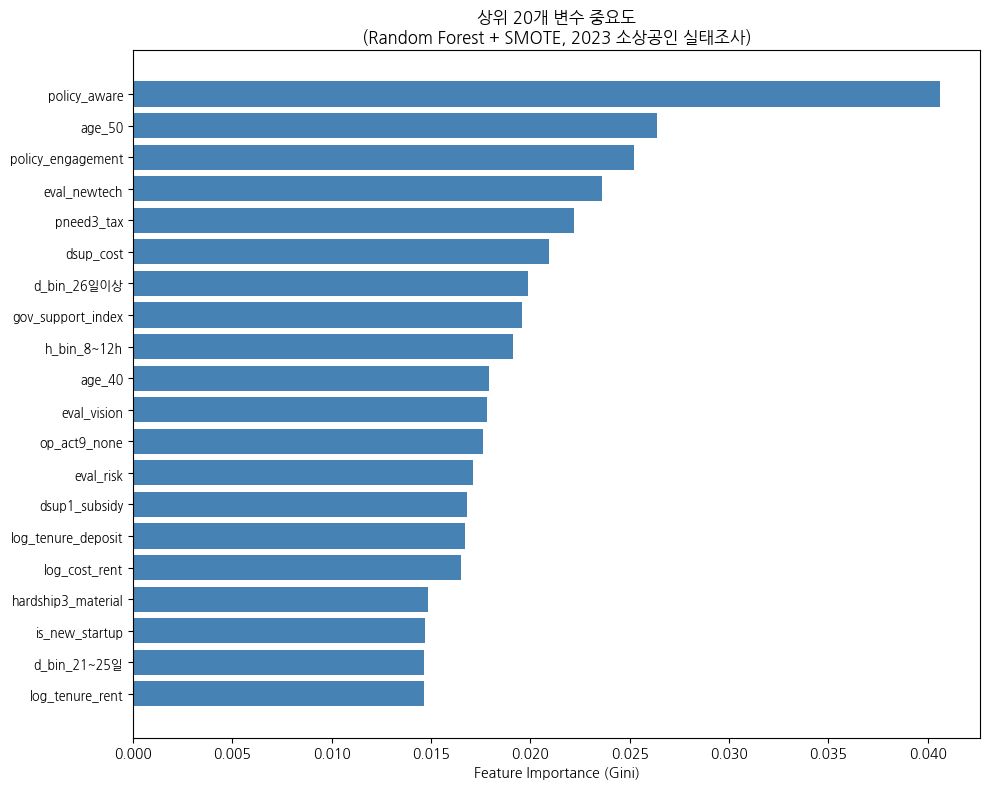

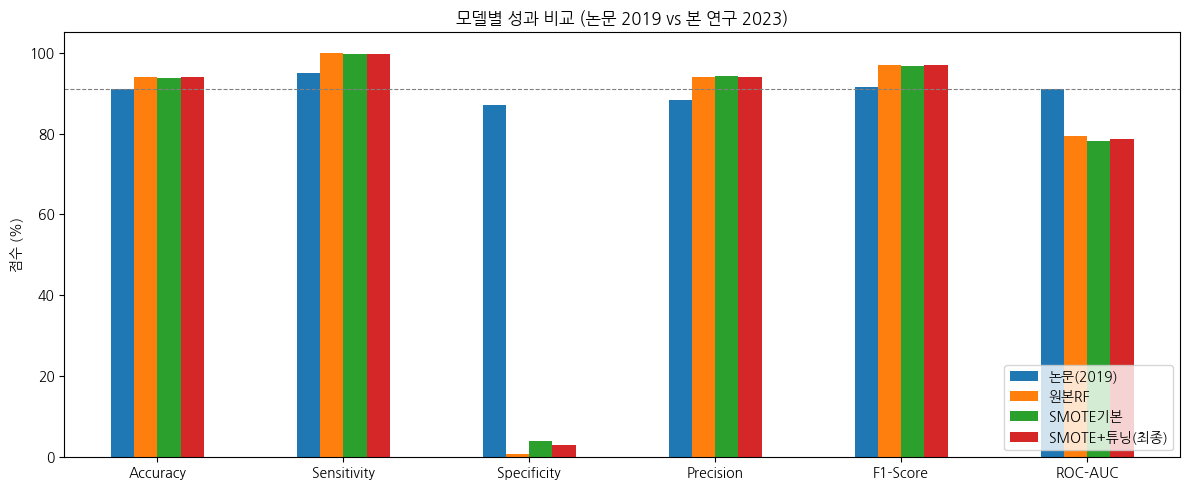

저장 완료


In [21]:
# 폰트 재등록
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 변수 중요도 재저장 ──
top20 = fi_df.head(20)
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top20['feature'][::-1].values, top20['importance'][::-1].values, color='steelblue')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('상위 20개 변수 중요도\n(Random Forest + SMOTE, 2023 소상공인 실태조사)')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 모델 비교 그래프 재저장 ──
ax2 = compare_df.T.plot(kind='bar', figsize=(12, 5), rot=0)
ax2.set_title('모델별 성과 비교 (논문 2019 vs 본 연구 2023)')
ax2.set_ylabel('점수 (%)')
ax2.set_ylim(0, 105)
ax2.legend(loc='lower right')
ax2.axhline(y=91.06, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('저장 완료')

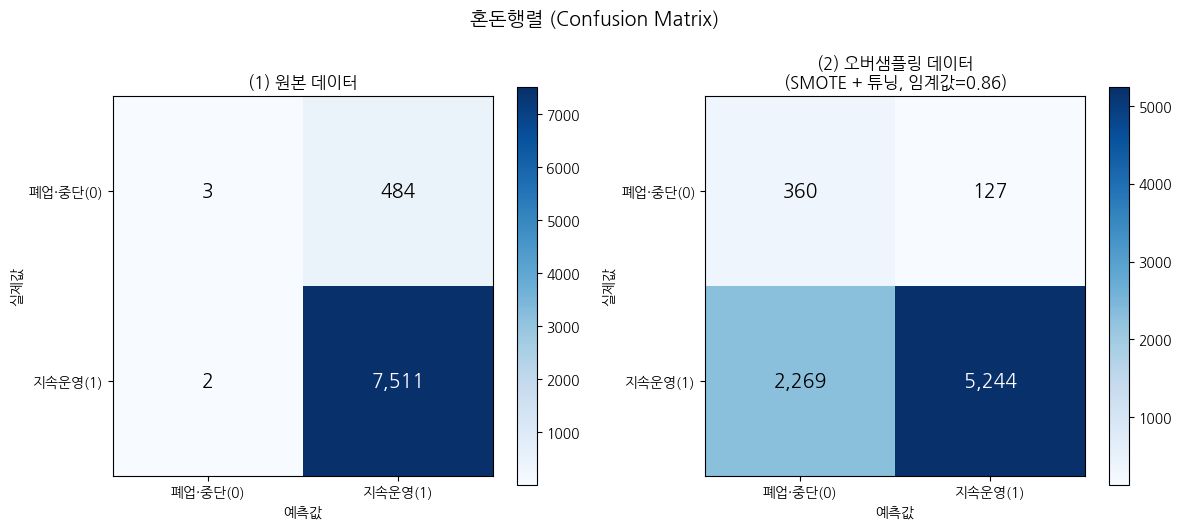

저장: paper_confusion_matrix.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
titles = ['(1) 원본 데이터', f'(2) 오버샘플링 데이터\n(SMOTE + 튜닝, 임계값={BEST_THRESHOLD})']
labels = ['폐업·중단(0)', '지속운영(1)']

for ax, res, title in zip(axes, [r_base, r_smote], titles):
    cm = res['cm']
    im = ax.imshow(cm, cmap='Blues')
    plt.colorbar(im, ax=ax)
    ax.set(xticks=[0,1], yticks=[0,1], xticklabels=labels, yticklabels=labels,
           title=title, ylabel='실제값', xlabel='예측값')
    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                    color='white' if cm[i,j]>thresh else 'black',
                    fontsize=14, fontweight='bold')

plt.suptitle('혼돈행렬 (Confusion Matrix)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(DRIVE+'paper_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: paper_confusion_matrix.png')


  지표                 논문(2019)         원본RF     SMOTE+튜닝
  ─────────────────────────────────────────────────────
  Accuracy             91.06%       93.92%       70.05%
  Sensitivity          95.00%       99.97%       69.80%
  Specificity          87.03%        0.62%       73.92%
  Precision            88.21%       93.95%       97.64%
  F1-Score             91.48%       96.87%       81.40%
  ROC-AUC              91.02%       79.28%       78.76%


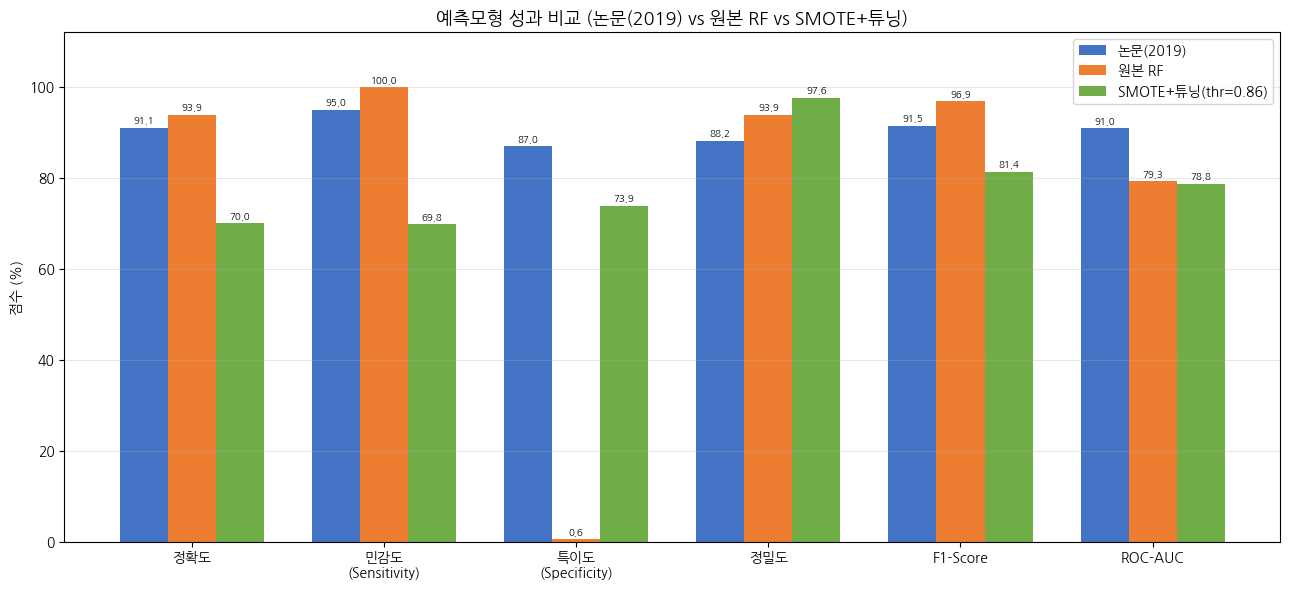

저장: paper_metrics_comparison.png


In [24]:
order = ['Accuracy','Sensitivity','Specificity','Precision','F1-Score','ROC-AUC']

# 콘솔 표
print(f"  {'지표':<15} {'논문(2019)':>11} {'원본RF':>12} {'SMOTE+튜닝':>12}")
print('  ' + '─'*53)
for m in order:
    print(f"  {m:<15} {PAPER[m]*100:>10.2f}%"
          f" {r_base['metrics'][m]*100:>11.2f}%"
          f" {r_smote['metrics'][m]*100:>11.2f}%")

# 바 차트
labels_kr = ['정확도','민감도\n(Sensitivity)','특이도\n(Specificity)',
             '정밀도','F1-Score','ROC-AUC']
x, w = np.arange(len(order)), 0.25

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x-w, [PAPER[m]*100 for m in order], w, label='논문(2019)', color='#4472C4')
b2 = ax.bar(x,   [r_base['metrics'][m]*100 for m in order], w, label='원본 RF', color='#ED7D31')
b3 = ax.bar(x+w, [r_smote['metrics'][m]*100 for m in order], w, label=f'SMOTE+튜닝(thr={BEST_THRESHOLD})', color='#70AD47')

ax.set_xticks(x); ax.set_xticklabels(labels_kr, fontsize=10)
ax.set_ylabel('점수 (%)'); ax.set_ylim(0, 112)
ax.set_title('예측모형 성과 비교 (논문(2019) vs 원본 RF vs SMOTE+튜닝)', fontsize=13)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.5, f'{h:.1f}',
                ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig(DRIVE+'paper_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: paper_metrics_comparison.png')


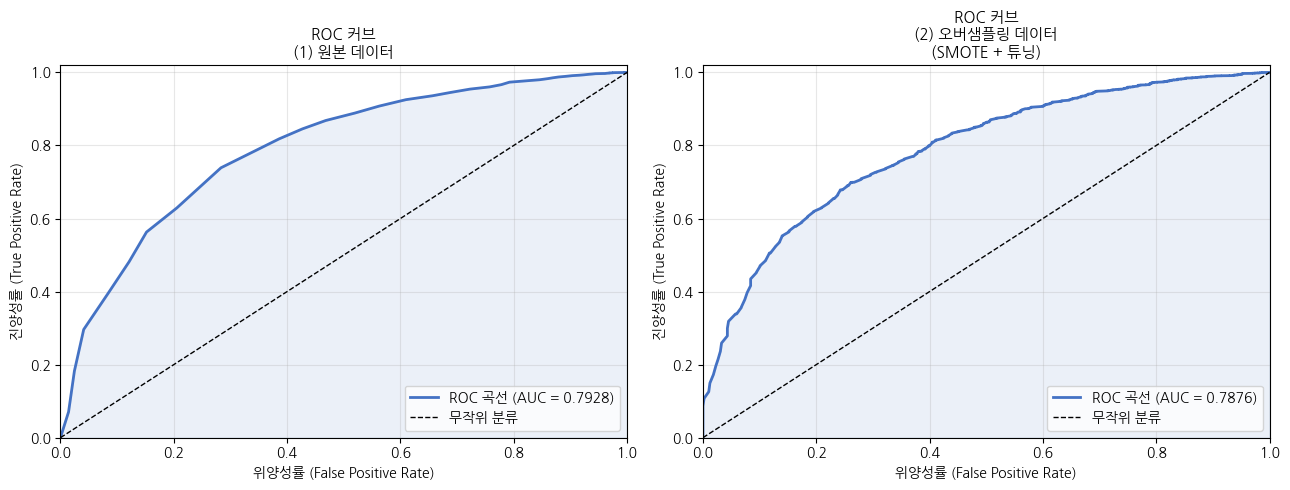

저장: paper_roc_curve.png


In [25]:
fpr_b, tpr_b, _ = roc_curve(y_test, r_base['y_prob'])
fpr_s, tpr_s, _ = roc_curve(y_test, r_smote['y_prob'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, fpr, tpr, title in zip(
    axes,
    [fpr_b, fpr_s], [tpr_b, tpr_s],
    ['(1) 원본 데이터', f'(2) 오버샘플링 데이터\n(SMOTE + 튜닝)']
):
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color='#4472C4', lw=2, label=f'ROC 곡선 (AUC = {auc_val:.4f})')
    ax.fill_between(fpr, tpr, alpha=0.1, color='#4472C4')
    ax.plot([0,1],[0,1],'k--',lw=1,label='무작위 분류')
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    ax.set_xlabel('위양성률 (False Positive Rate)')
    ax.set_ylabel('진양성률 (True Positive Rate)')
    ax.set_title(f'ROC 커브\n{title}', fontsize=11)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(DRIVE+'paper_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: paper_roc_curve.png')


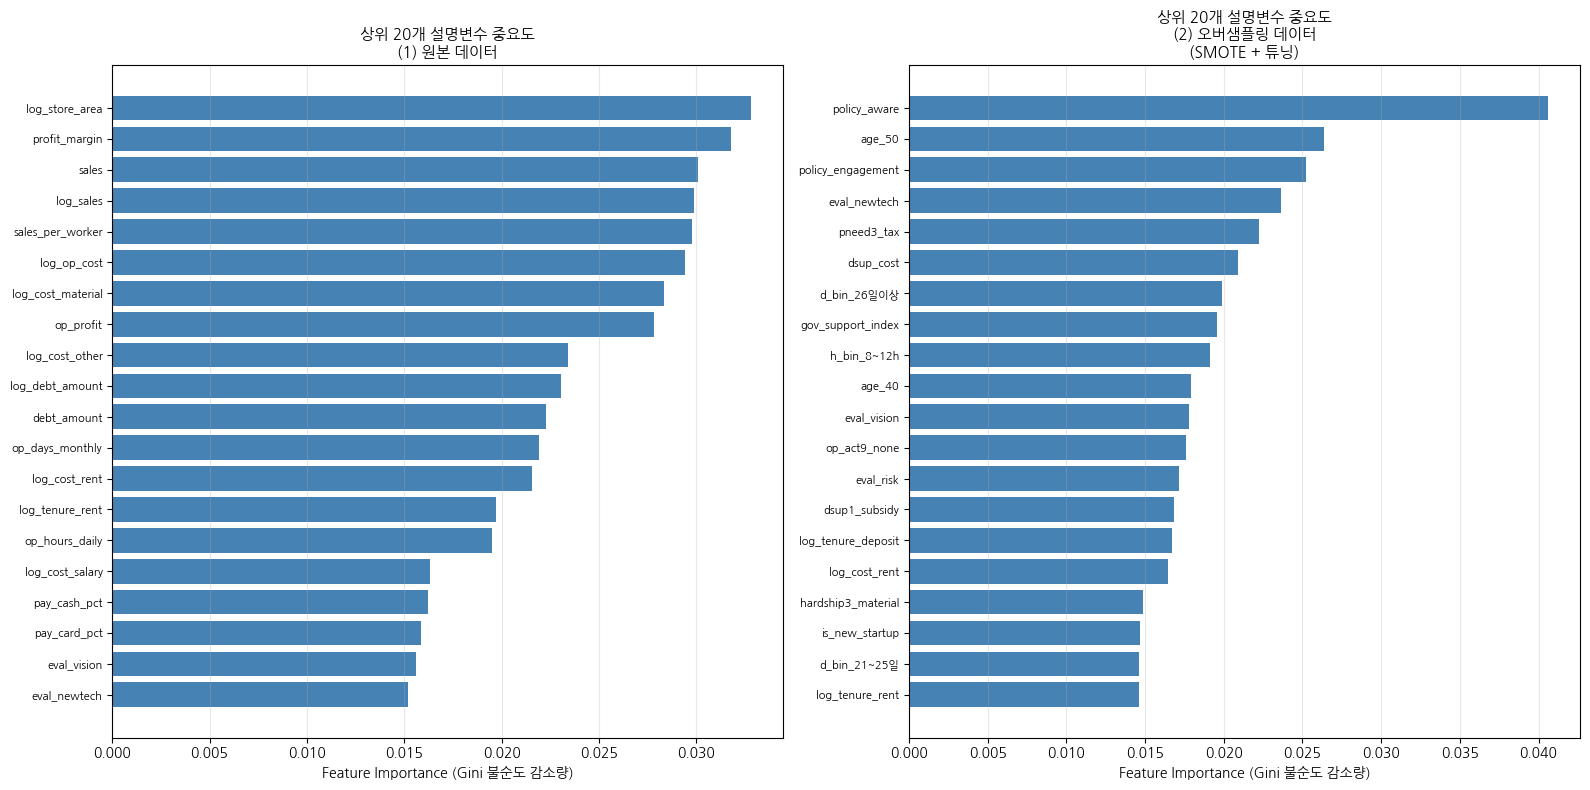

저장: paper_feature_importance.png


In [26]:
import pandas as pd

fi_base = pd.DataFrame({'feature':X.columns,
    'importance':rf_base.feature_importances_}
).sort_values('importance',ascending=False).head(20)

fi_smote = pd.DataFrame({'feature':X.columns,
    'importance':search.best_estimator_.feature_importances_}
).sort_values('importance',ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, fi, title in zip(axes, [fi_base, fi_smote],
    ['(1) 원본 데이터', '(2) 오버샘플링 데이터\n(SMOTE + 튜닝)']):
    ax.barh(fi['feature'][::-1], fi['importance'][::-1], color='steelblue')
    ax.set_xlabel('Feature Importance (Gini 불순도 감소량)')
    ax.set_title(f'상위 20개 설명변수 중요도\n{title}', fontsize=11)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(DRIVE+'paper_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: paper_feature_importance.png')


In [27]:
# 원본 RF에 임계값 최적화 적용
y_prob_base = rf_base.predict_proba(X_test)[:, 1]

thr_records_b = []
for thr in np.arange(0.05, 0.95, 0.01):
    y_pred_t = (y_prob_base >= thr).astype(int)
    if len(np.unique(y_pred_t)) < 2:
        continue
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    sens  = tp/(tp+fn) if (tp+fn)>0 else 0
    spec  = tn/(tn+fp) if (tn+fp)>0 else 0
    gmean = np.sqrt(sens * spec)
    thr_records_b.append({'threshold': round(thr,2),
                          'Sensitivity': sens, 'Specificity': spec, 'G-mean': gmean})

thr_df_b = pd.DataFrame(thr_records_b)
best_b   = thr_df_b.loc[thr_df_b['G-mean'].idxmax()]
print(f'원본RF 최적 임계값: {best_b["threshold"]}')
print(f'  Sensitivity : {best_b["Sensitivity"]*100:.2f}%')
print(f'  Specificity : {best_b["Specificity"]*100:.2f}%')
print(f'  G-mean      : {best_b["G-mean"]*100:.2f}%')

원본RF 최적 임계값: 0.91
  Sensitivity : 73.90%
  Specificity : 71.66%
  G-mean      : 72.77%
